# PCA Digit Classification

Use PCA for dimensionality reduction, train a logistic regression classifier, and test it on one digit image.

This notebook uses scikit-learn's built-in digits dataset so it runs without downloading MNIST.

In [1]:
# 1. Import statements
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [21]:
# 2. Getting the dataset
digits = load_digits()
X = digits.data
y = digits.target

print('Original feature shape:', X.shape)
print('Image shape:', digits.images[0].shape)


Original feature shape: (1797, 64)
Image shape: (8, 8)


In [3]:
# 3. Splitting and scaling the dataset
X_train, X_test, y_train, y_test, image_train, image_test = train_test_split(
    X,
    y,
    digits.images,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [17]:
# 4. Applying PCA for dimensionality reduction
pca = PCA(n_components=0.99, random_state=42)
X_train_reduced = pca.fit_transform(X_train_scaled)
X_test_reduced = pca.transform(X_test_scaled)

print('Reduced training shape:', X_train_reduced.shape)
print('Reduced testing shape:', X_test_reduced.shape)
print('Explained variance ratio:', sum(pca.explained_variance_ratio_))

Reduced training shape: (1437, 54)
Reduced testing shape: (360, 54)
Explained variance ratio: 0.9910178699468193


In [18]:
# 5. Applying the classification algorithm
classifier = LogisticRegression(max_iter=2000)
classifier.fit(X_train_reduced, y_train)

y_pred = classifier.predict(X_test_reduced)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy after PCA: {accuracy:.3f}')


Accuracy after PCA: 0.975


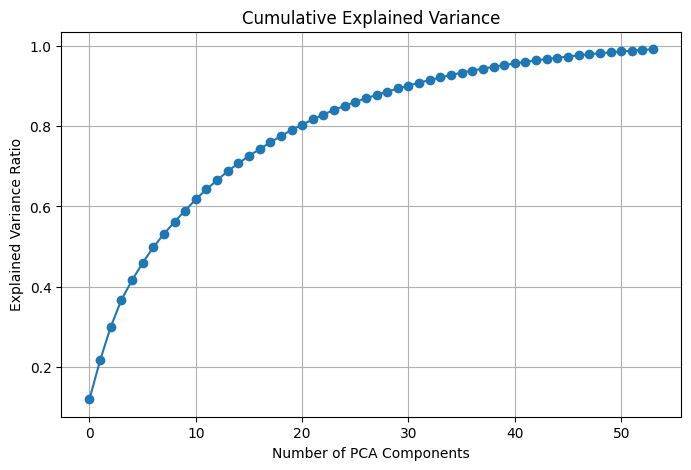

In [19]:
# 6. Graphing explained variance
plt.figure(figsize=(8, 5))
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()


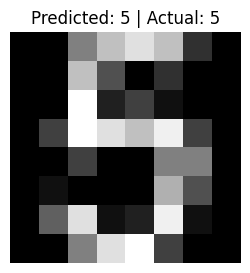

Predicted digit: 5
Actual digit: 5


In [20]:
# 7. Testing against one datapoint
sample_index = 0
sample = X_test[sample_index].reshape(1, -1)
sample_scaled = scaler.transform(sample)
sample_reduced = pca.transform(sample_scaled)
prediction = classifier.predict(sample_reduced)[0]
actual = y_test[sample_index]

plt.figure(figsize=(3, 3))
plt.imshow(image_test[sample_index], cmap='gray')
plt.title(f'Predicted: {prediction} | Actual: {actual}')
plt.axis('off')
plt.show()

print('Predicted digit:', prediction)
print('Actual digit:', actual)
